<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Standard-Data-Science-Packages" data-toc-modified-id="Import-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Standard Data Science Packages</a></span><ul class="toc-item"><li><span><a href="#Set-Colorblind-Friendly-Palette" data-toc-modified-id="Set-Colorblind-Friendly-Palette-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Set Colorblind-Friendly Palette</a></span></li></ul></li><li><span><a href="#Load-and-Visualise-dPCR-Data" data-toc-modified-id="Load-and-Visualise-dPCR-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load and Visualise dPCR Data</a></span></li><li><span><a href="#Data-Analysis" data-toc-modified-id="Data-Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Analysis</a></span><ul class="toc-item"><li><span><a href="#Organise-Data" data-toc-modified-id="Organise-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Organise Data</a></span></li><li><span><a href="#Define-ACA-Model-(Neural-Network)" data-toc-modified-id="Define-ACA-Model-(Neural-Network)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Define ACA Model (Neural Network)</a></span></li><li><span><a href="#Train-and-Compute-Performance-(10-Fold-Cross-Val)" data-toc-modified-id="Train-and-Compute-Performance-(10-Fold-Cross-Val)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Train and Compute Performance (10-Fold Cross Val)</a></span></li><li><span><a href="#Visualise-AMCA-Coefficients" data-toc-modified-id="Visualise-AMCA-Coefficients-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Visualise AMCA Coefficients</a></span></li><li><span><a href="#Compute-Performance-as-a-Function-of-Training-Volume" data-toc-modified-id="Compute-Performance-as-a-Function-of-Training-Volume-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Compute Performance as a Function of Training Volume</a></span></li></ul></li></ul></div>

# Import Standard Data Science Packages

In [75]:
%load_ext autoreload
%autoreload
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

import chip_utilities as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set Colorblind-Friendly Palette

In [8]:
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0, 0.45, 0.70),    # Blue
                                                (0.9, 0.6, 0.0),     # Orange
                                                (0.0, 0.60, 0.50),    # Bluish Green
                                                (0.8, 0.4, 0),       # Vermillion/Burnt Orange
                                                (0.35, 0.7, 0.9),    # Sky Blue
                                                (0.8, 0.6, 0.7),     # Reddish Purple/Pink
                                                (0, 0, 0),           # Black
                                                (0.5, 0.5, 0.5),     # Grey
                                                (0.286, 0, 0.573),   # Deep Purple
                                                (0.8, 0.1, 0.3)]])   # 10th: Berry Red

# Load and Visualise dPCR Data

In [86]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/trial test data/"
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")
sigmoid_data_path = f'{exp_path}/normalised_ori_ac_df.csv'

chip_data = pd.read_csv(sigmoid_data_path)
chip_data = utils.denormalized(chip_data)
chip_data.head()

,row_min,row_max,row_range,well,Cycle71.10000000000001,Cycle74.89999999999999,Cycle78.7,Cycle82.49999999999999,Cycle86.3,Cycle90.10000000000001,...,Cycle2364.4,Cycle2368.2000000000003,Cycle2372.0,Cycle2375.8,Cycle2379.6000000000004,Cycle2383.4,Cycle2387.1000000000004,Cycle2390.9,Cycle2394.7000000000003,Cycle2398.5
0,0.209451,0.239304,0.029854,0,0.219883,0.225581,0.221032,0.223199,0.226792,0.220374,...,0.237564,0.233608,0.236609,0.236990,0.234911,0.234537,0.236800,0.237373,0.238334,0.233423
1,0.197048,0.227095,0.030047,0,0.219883,0.225896,0.222948,0.219505,0.218379,0.214700,...,0.223727,0.223143,0.222368,0.219316,0.215609,0.224511,0.221597,0.225499,0.223923,0.226494
2,0.190823,0.223456,0.032633,0,0.219883,0.215283,0.218522,0.220078,0.218136,0.211950,...,0.221062,0.219298,0.223255,0.216987,0.221062,0.220864,0.221259,0.222253,0.221259,0.223456
3,0.201863,0.221085,0.019222,0,0.219883,0.218566,0.215485,0.221085,0.219090,0.216118,...,0.214233,0.215359,0.215233,0.216373,0.212877,0.213738,0.213245,0.216245,0.214607,0.210822
4,0.203428,0.228837,0.025409,0,0.219883,0.223504,0.219256,0.222212,0.222212,0.211433,...,0.227704,0.225473,0.226359,0.224812,0.225473,0.224593,0.228837,0.226137,0.225473,0.225915


In [90]:
y_lim_min, y_lim_max = chip_data.filter(like="Cycle").values.min(), chip_data.filter(like="Cycle").values.max()

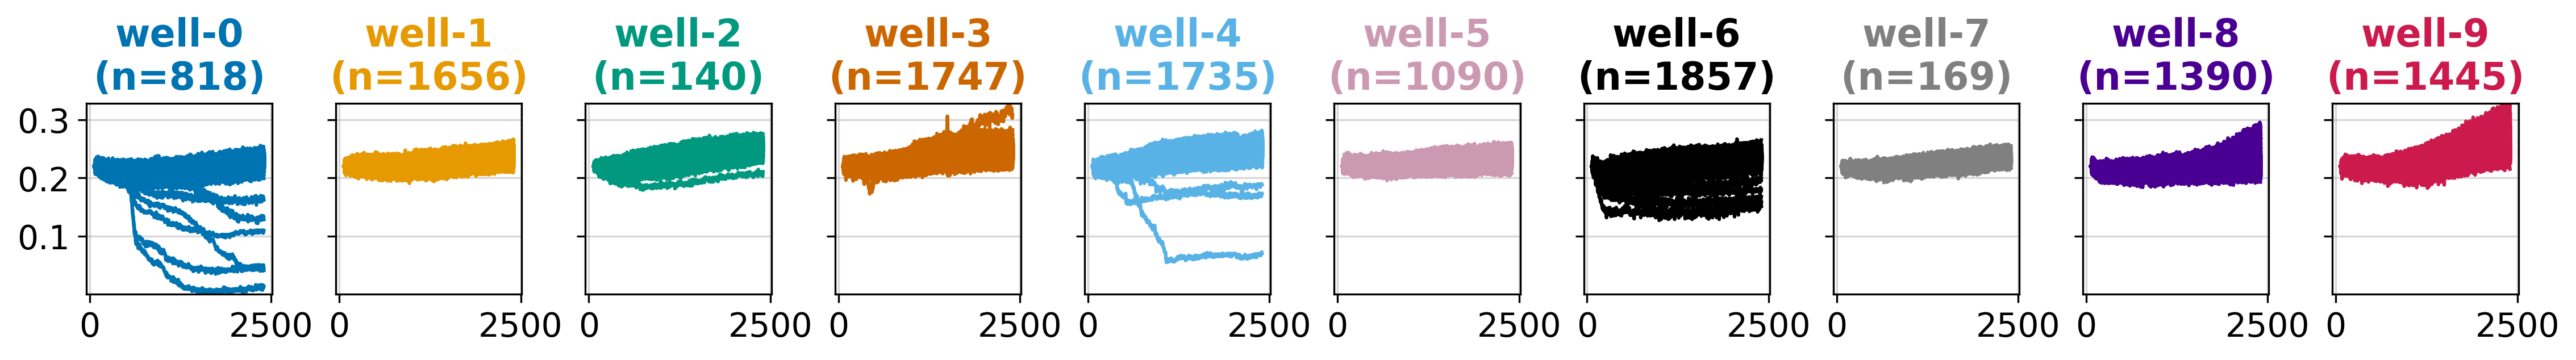

In [ ]:
utils.plot_amplification_curves(chip_data, ylim=(y_lim_min, y_lim_max))

In [67]:
# filename = 'Images/dPCR_melting_peaks.png'
# utils.plot_melt_peak_distributions(df_dpcr_ampl, filename=filename)

In [68]:
# df_dpcr_melt = pd.read_csv('Data/dPCR_Melting_Curves.csv', 
#                            index_col=0)

# df_dpcr_melt.head()

In [69]:
# filename = 'Images/dPCR_melting_curves.png'
# utils.plot_melt_curves(df_dpcr_melt, NMETA=7, ylim=(0, 0.12), filename=filename)

# Data Analysis
## Organise Data

In [112]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV

X_AC = chip_data.filter(like="Cycle").values
# X_MC = df_dpcr_ampl.loc[:, ['MeltPeaks']].values
X_FFI = X_AC[:,[-1]]

encoder = LabelEncoder()
encoder.fit(chip_data['well'])
ytrue = encoder.transform(chip_data['well'])

X_AC.shape, X_FFI.shape, ytrue.shape

((12047, 615), (12047, 1), (12047,))

array([0, 0, 0, ..., 9, 9, 9], shape=(12047,))

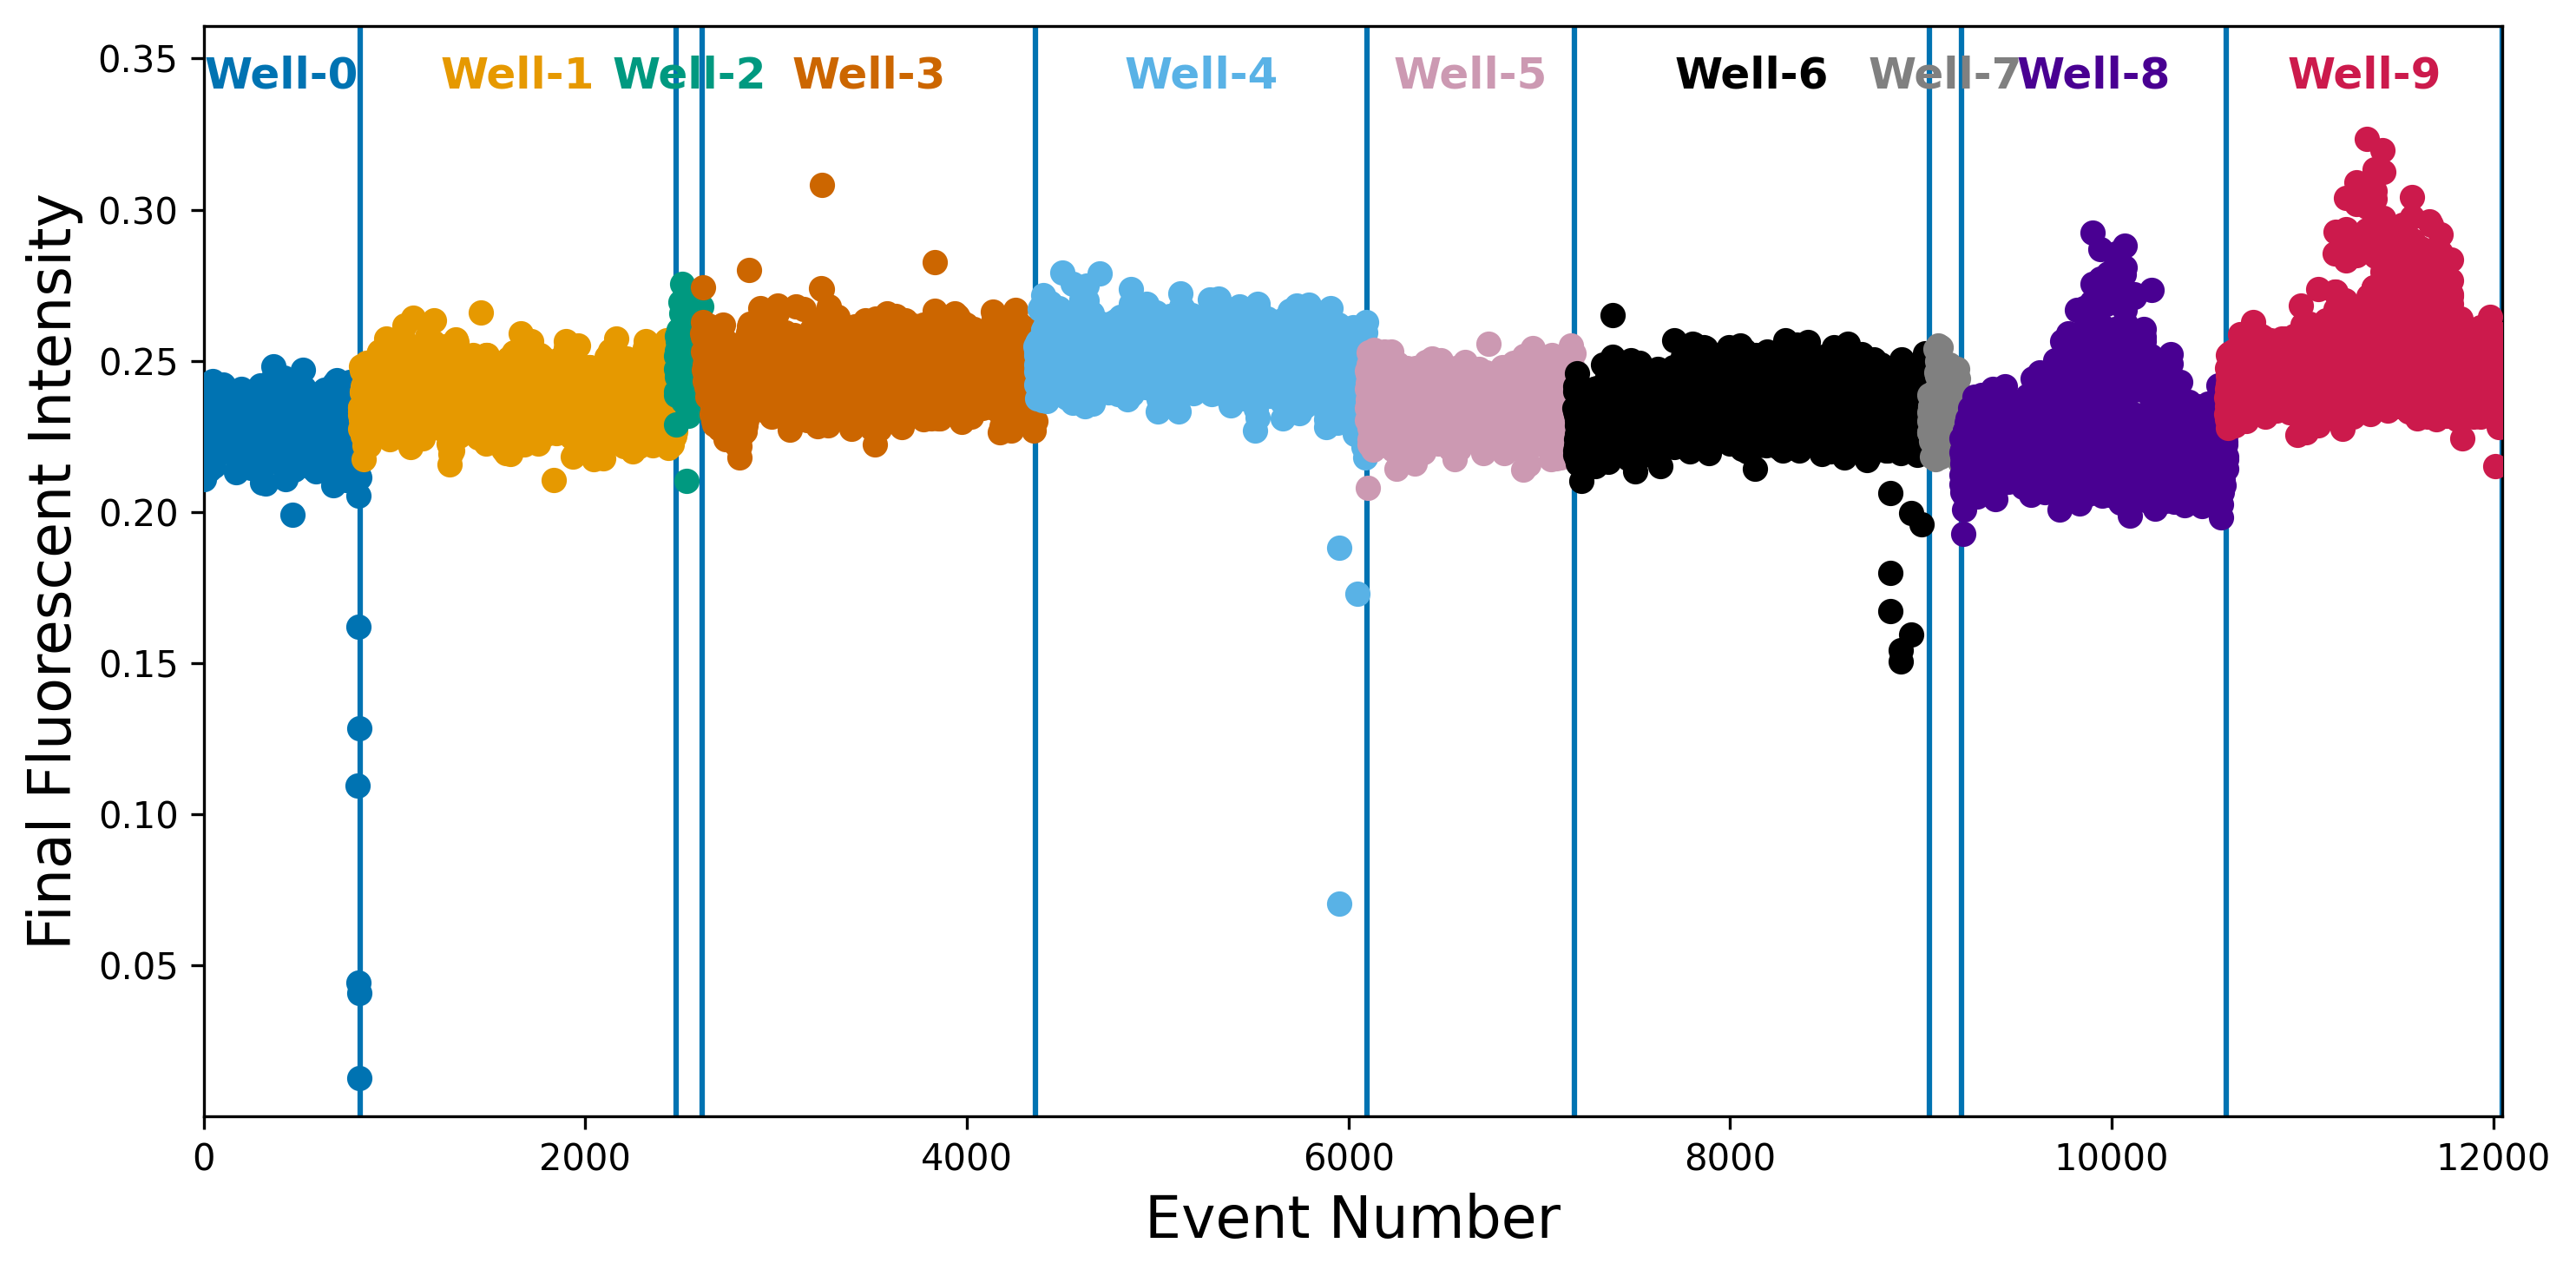

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)

cnt = 0
for i in np.unique(ytrue):
    idx = ytrue==i
    ax.scatter(np.arange(np.sum(idx)) + cnt, X_FFI[idx], color=f'C{i}', zorder=100)
    
    ax.text(cnt + np.sum(idx)/2, y_lim_max*1.05, f"Well-{encoder.classes_[i]}", color=f'C{i}', fontsize=12, weight='bold',
            horizontalalignment='center', verticalalignment='center')
    
    cnt += np.sum(idx)
    
    ax.vlines(cnt, y_lim_min, y_lim_max*1.1)
    
    
ax.set_xlim((0, len(X_FFI)))
ax.set_ylim((y_lim_min, y_lim_max*1.1))

ax.set_ylabel('Final Fluorescent Intensity', fontsize=16)
ax.set_xlabel('Event Number', fontsize=16)

# ax.grid(True)

plt.tight_layout()
# plt.savefig('Images/dPCR_FFI_Dist.png')
plt.show()

615

## Define ACA Model (Neural Network)

In [116]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

class myWrapper(KerasClassifier):
    # def predict(self, X):
    #     return self.model.predict(X).argmax(axis=1)
    
    # def predict_proba(self, X):
    #     return self.model.predict(X)
    pass

display(f'TF VERSION: {tf.__version__}')

def create_model(): # 70% WE USED FOR THE FIRST TIME TNSOR BOARD
    # TIMESTEPS, CHANNELS
    inputs = tf.keras.layers.Input(shape=(X_AC.shape[1], 1))
    x = tf.keras.layers.Conv1D(16, 5, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(8, 3, activation='relu')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(len(np.unique(ytrue)), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=inputs, outputs=x)
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

tf_net = create_model()
tf_net.summary()

'TF VERSION: 2.21.0'

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 615, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 611, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 609, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        48,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,218 (192.26 KB)

 Trainable params: 49,218 (192.26 KB)

 Non-trainable params: 0 (0.00 B)

## Train and Compute Performance (10-Fold Cross Val)

In [ ]:
N_SPLITS = 10

kfolds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
splits = kfolds.split(X_AC, ytrue)

y_trues_ = []
y_preds_ = []

y_preds_AC_ = []
y_preds_MC_ = []
y_preds_FFI_ = []
    
for i, (train_index, test_index) in enumerate(tqdm(splits, total=N_SPLITS)):

    # X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
    X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
    X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]
    
    y_train, y_test = ytrue[train_index], ytrue[test_index]
    
    ########## create/train model for MC ##########    
    # clf_MC = LogisticRegression(max_iter=1000)
    # clf_MC.fit(X_MC_train, y_train)
    # clf_MC_proba = clf_MC.predict_proba(X_MC_train)
        
    ########## create/train model for AC ##########
    clf_AC = myWrapper(build_fn=create_model, 
                            epochs=1000, 
                            batch_size=512, 
                            shuffle=True,
                            verbose=False)
    clf_AC.fit(X_AC_train, y_train)
    # clf_AC_proba = clf_AC.predict_proba(X_AC_train)
    
    ########## create/train model for FFI ##########
    clf_FFI = LogisticRegression(max_iter=1000)
    clf_FFI.fit(X_FFI_train, y_train)
    # clf_FFI_proba = clf_FFI.predict_proba(X_FFI_train)
        
    ########## create/train model for AMCA ##########
    # X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)
    
    # clf = LogisticRegression(max_iter=1000, fit_intercept=False)
    # clf.fit(X_AMCA_train, y_train)
    # clf_proba = clf.predict_proba(X_AMCA_train)

    ########## Test models ##########
    y_preds_AC_.append( clf_AC.predict(X_AC_test) )
    # y_preds_MC_.append( clf_MC.predict(X_MC_test) )
    y_preds_FFI_.append( clf_FFI.predict(X_FFI_test) )
    
    # X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
    #                                clf_AC.predict_proba(X_AC_test)), axis=1)
    
    # y_pred = clf.predict(X_AMCA_test)
    
    # y_preds_.append( y_pred )
    y_trues_.append( y_test )

    
y_trues = np.concatenate(y_trues_)
# y_preds = np.concatenate(y_preds_)

y_preds_AC = np.concatenate(y_preds_AC_)
# y_preds_MC = np.concatenate(y_preds_MC_)
y_preds_FFI = np.concatenate(y_preds_FFI_)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 10%|█         | 1/10 [04:17<38:41, 257.93s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 20%|██        | 2/10 [08:30<33:59, 254.92s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/

In [152]:
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from scipy.stats import bartlett, ttest_ind

acc_for_each_fold = lambda x: [accuracy_score(i, j) for i, j in zip(x, y_trues_)]

acc_dict = {'FFI': acc_for_each_fold(y_preds_FFI_),
            'ACA': acc_for_each_fold(y_preds_AC_),
            # 'MCA': acc_for_each_fold(y_preds_MC_),
            # 'AMCA': acc_for_each_fold(y_preds_)
            }
acc = pd.DataFrame(acc_dict)

normality_test = lambda x: sm.stats.lilliefors(x)[1]

# variance_test = lambda x: bartlett(x, acc['AMCA'])[1]

# ttest = lambda x: ttest_ind(x, acc['AMCA'], equal_var=False)[1]

# statistics = lambda x: [np.mean(x), np.std(x), normality_test(x), variance_test(x), ttest(x)]

# stats = pd.DataFrame({k: statistics(acc[k]) for k in acc.columns})

# stats.index = ['Mean Acc.', 'Std Acc.', 'Normality p-val.', 'Equal Var. p-val', 'Ttest p-val']

# pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# stats

In [163]:
# pd.DataFrame({'True': y_trues,'FFI': y_preds_FFI, 'ACA': y_preds_AC, 'MCA': y_preds_MC, 'AMCA': y_preds}).to_csv('Data/my_preds.csv')
pd.DataFrame({'True': y_trues,'FFI': y_preds_FFI, 'ACA': y_preds_AC}).to_csv('Data/my_preds.csv')

In [79]:
np.save('Data/my_coeff', clf.coef_)

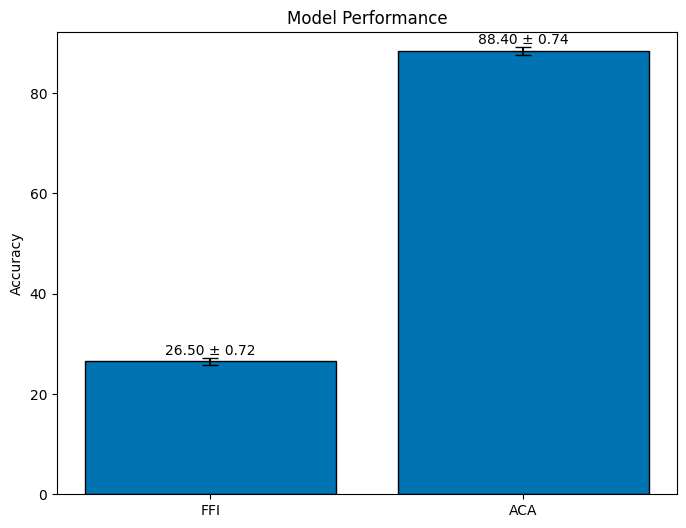

In [171]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI_, y_preds_AC_] #, y_preds_MC_, y_preds_]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis'] #,
        #   'Melting Curve Analysis',
        #   'Amplification and Melting Curve Analysis']
short_names = ['FFI', 'ACA']#, 'MCA', 'AMCA']
accs_mean = []
accs_std = []
for yps in ypreds_methods:
    acc_temp = []
    for yp, y_tr in zip(yps, y_trues_):
        acc_temp.append(accuracy_score(y_tr, yp)*100)
    accs_mean.append(np.mean(acc_temp))
    accs_std.append(np.std(acc_temp))

custom_labels = [f'{a:.2f} ± {s:.2f}' for a, s in zip(accs_mean, accs_std)]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(short_names, accs_mean, yerr=accs_std, capsize=6, edgecolor='black')
ax.bar_label(bars, labels=custom_labels, padding=0, fontsize=10)
ax.set_ylim(0, max(accs_mean) + max(accs_std) + 3)
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance')

plt.show()

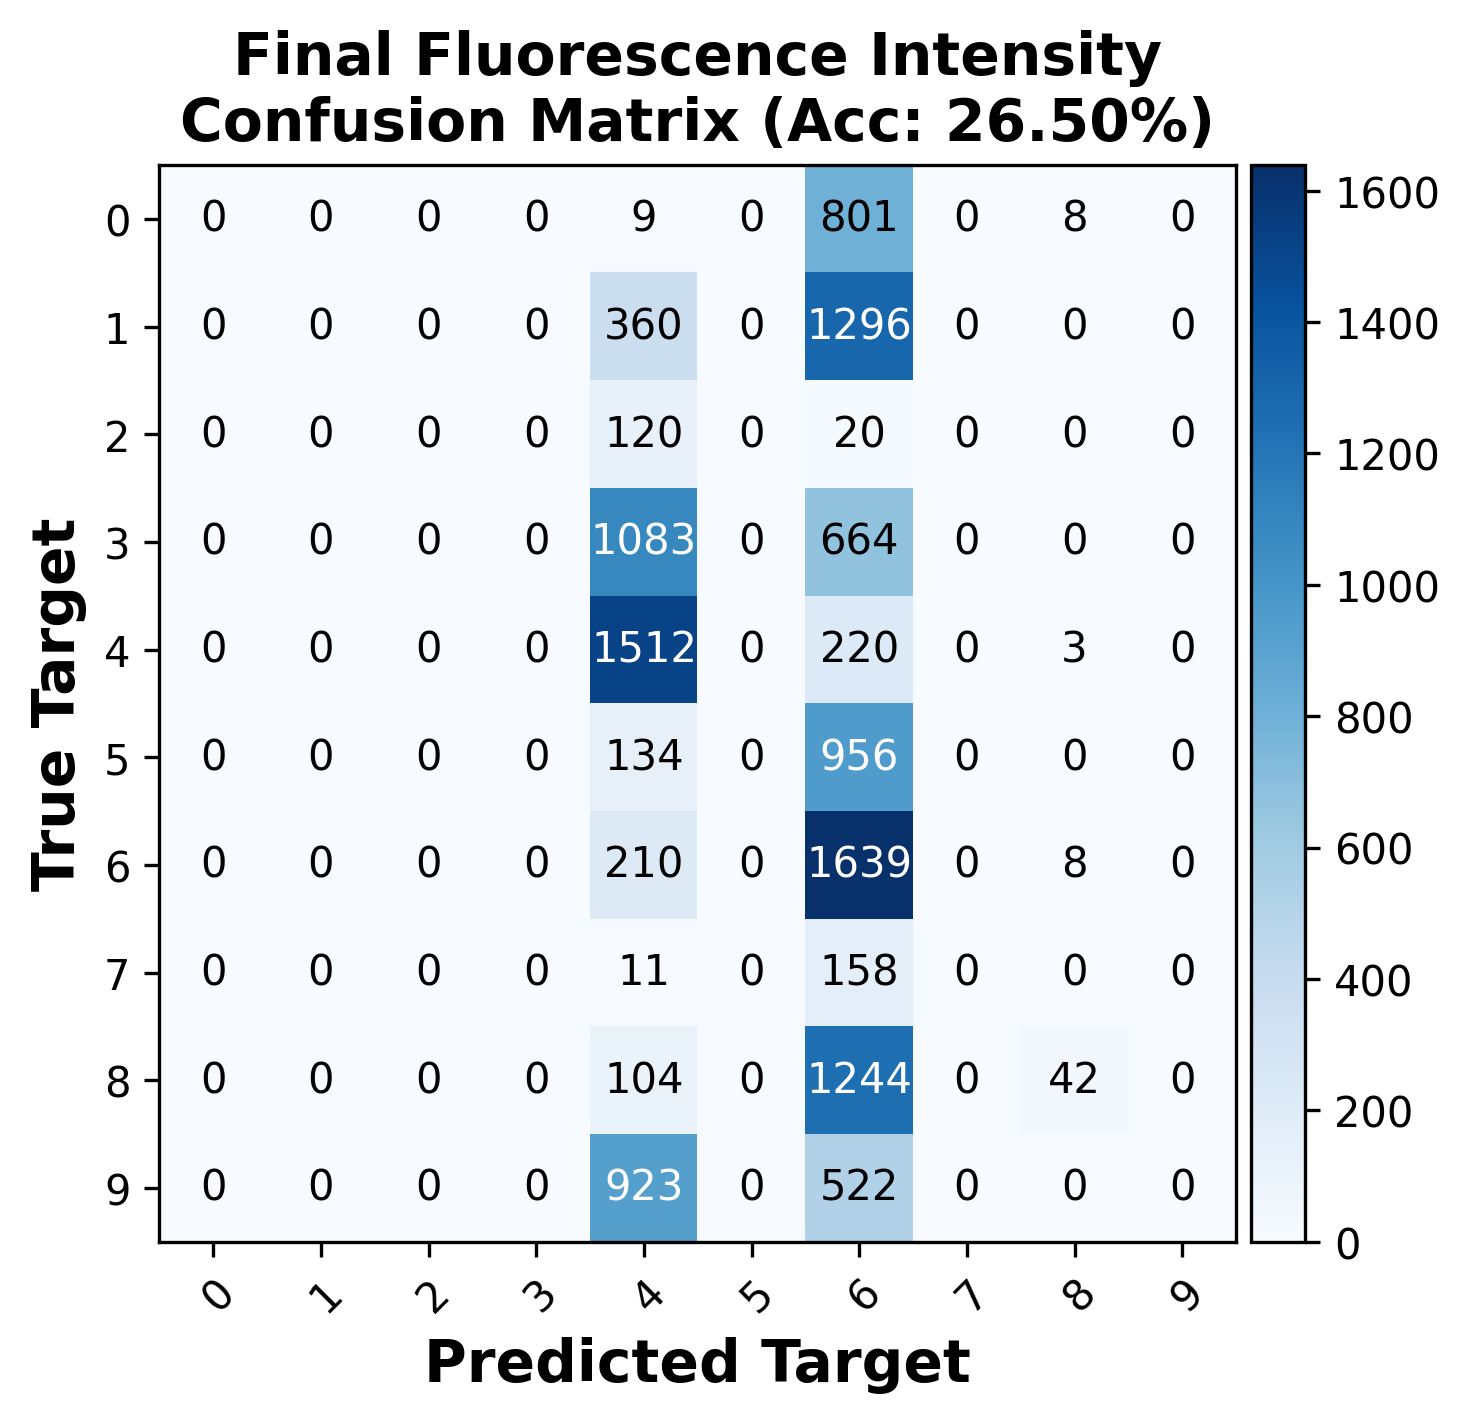

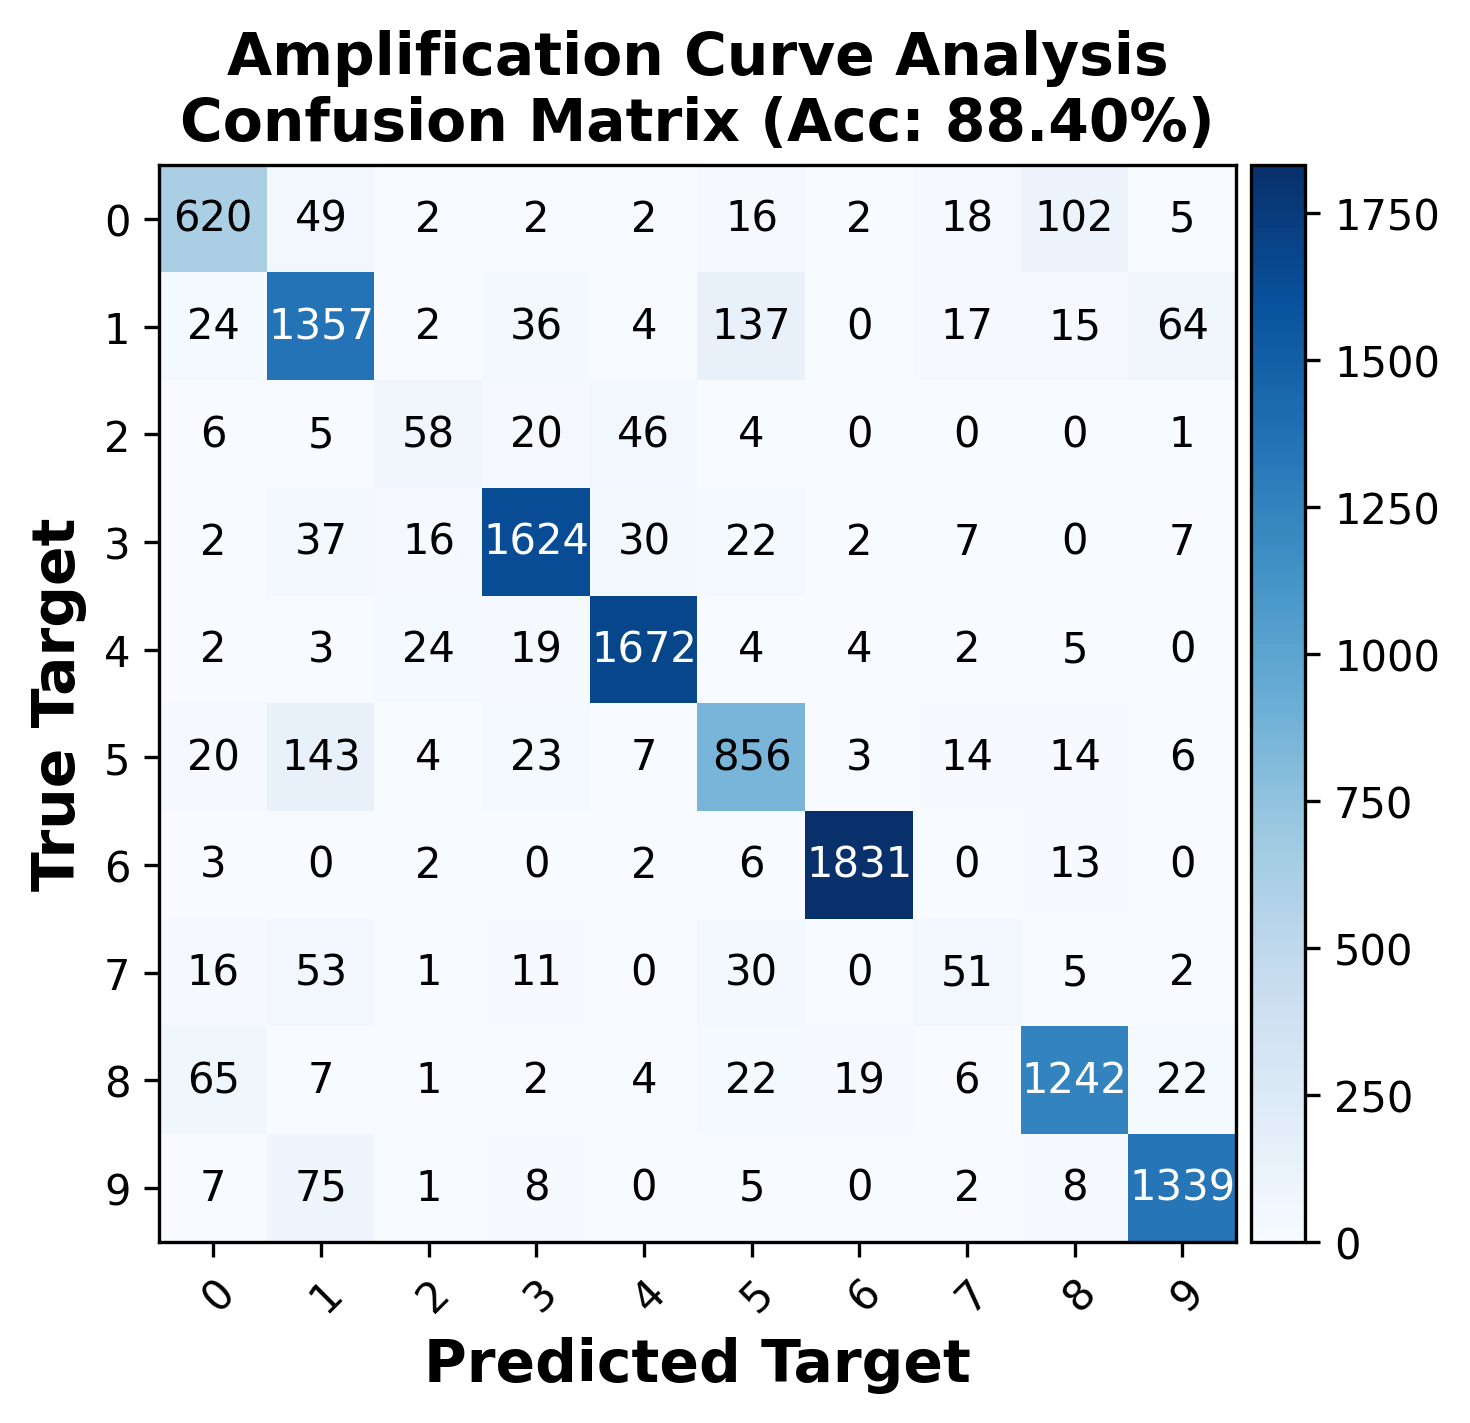

In [172]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI, y_preds_AC] #, y_preds_MC, y_preds]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis']
        #   ,
        #   'Melting Curve Analysis',
        #   'Amplification and Melting Curve Analysis']
short_names = ['FFI', 'ACA'] #, 'MCA', 'AMCA']

for yp, title, short_name in zip(ypreds_methods, titles, short_names):

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    utils.plot_confusion_matrix(y_trues, yp, classes, ax, normalize=False)
    ax.set_title(f'{title}\n'+ax.get_title(), fontsize=14, weight='bold')
    ax.set_ylabel('True Target', fontsize=14, weight='bold')
    ax.set_xlabel('Predicted Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}.pdf')
    plt.show()

In [174]:
from sklearn.metrics import accuracy_score, confusion_matrix

np.set_printoptions(precision=3, suppress=True)

a = 100*confusion_matrix(y_trues, y_preds_AC, normalize='true')

a.sum(axis=1) - np.diagonal(a)

array([24.205, 18.056, 58.571,  7.041,  3.631, 21.468,  1.4  , 69.822,
       10.647,  7.336])

## Visualise AMCA Coefficients

In [176]:
# ACA_coef = clf.coef_[:,:9]
# MCA_coef = clf.coef_[:,-9:]
    
# coefs = [ACA_coef, MCA_coef]
# short_names = ['ACA', 'MCA']
    
# for coef, short_name in zip(coefs, short_names):
    
#     fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

#     ax.set_xticks(range(9))
#     ax.set_yticks(range(9))
#     ax.set_xticklabels(classes)
#     ax.set_yticklabels(classes)
#     utils.my_heatmap(coef, ax, sns.cm.rocket_r)
#     ax.set_title(f'{short_name} Coefficients', fontsize=14, weight='bold')
#     ax.set_ylabel('Target', fontsize=14, weight='bold')
#     ax.set_xlabel('Target', fontsize=14, weight='bold')

#     plt.tight_layout()
#     plt.savefig(f'Images/dPCR_{short_name}_coeffs.pdf')
#     plt.show()

## Compute Performance as a Function of Training Volume

In [185]:
from sklearn.model_selection import StratifiedShuffleSplit
import datetime

n_total = len(X_AC)
# assert len(X_AC)==len(X_MC)==len(X_FFI), "Something is wrong!"

n_repeat = 1
n_train_sizes = 20
test_size = 5000

train_size = (10**np.linspace(2, np.log10(n_total-test_size), num=n_train_sizes))/n_total
# train_size = np.linspace(50, n_total-test_size, num=n_train_sizes) / n_total

accuracy = pd.DataFrame(columns = ['Method', 'TrainSize', 'Train/Test', 'Accuracy', 'Repeat ID'])

for size in tqdm(train_size, desc='Train Size Split'):
    
    sss = StratifiedShuffleSplit(n_splits=n_repeat, test_size=test_size/n_total, random_state=5)

    for split_id, (train_index, test_index) in tqdm(enumerate(sss.split(X_AC, ytrue)), 
                                                    total=n_repeat, desc='Repeat', leave=False):
        
        # X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
        X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
        X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]

        y_train, y_test = ytrue[train_index], ytrue[test_index]

        # X_MC_train = X_MC_train[:int(len(X_MC_train)*size), :]
        X_AC_train = X_AC_train[:int(len(X_AC_train)*size), :]
        X_FFI_train = X_FFI_train[:int(len(X_FFI_train)*size), :]
        y_train = y_train[:int(len(y_train)*size)]

        ########## create/train model for MC ##########    
        # clf_MC = LogisticRegression(max_iter=1000, solver='lbfgs', 
        #                             multi_class='auto')
        # clf_MC.fit(X_MC_train, y_train)
        # clf_MC_proba = clf_MC.predict_proba(X_MC_train)

        ########## create/train model for AC ##########
        clf_AC = myWrapper(build_fn=create_model, 
                                epochs=800, 
                                batch_size=512, 
                                shuffle=True,
                                verbose=False)

#         clf_AC = KNeighborsClassifier(n_neighbors=10)
        clf_AC.fit(X_AC_train, y_train)
        clf_AC_proba = clf_AC.predict_proba(X_AC_train)

        ########## create/train model for FFI ##########
        clf_FFI = LogisticRegression(max_iter=1000, solver='lbfgs', 
                                    multi_class='auto')
        clf_FFI.fit(X_FFI_train, y_train)
        clf_FFI_proba = clf_FFI.predict_proba(X_FFI_train)

        ########## create/train model for AMCA ##########
        # X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)

        # clf = LogisticRegression(max_iter=1000, fit_intercept=False, 
        #                          solver='lbfgs', multi_class='auto')
        # clf = LogisticRegressionCV(max_iter=2000, fit_intercept=False,
        #                            cv=StratifiedKFold(n_splits=5, shuffle=True))

        # clf.fit(X_AMCA_train, y_train)
        # clf_proba = clf.predict_proba(X_AMCA_train)

        # clf_MC_proba.argmax(axis=1) is the same as clf_MC.predict(X_MC_train)
        # MCA_train_accuracy = (clf_MC_proba.argmax(axis=1)==y_train).mean()
        ACA_train_accuracy = (clf_AC_proba.argmax(axis=1)==y_train).mean()
        FFI_train_accuracy = (clf_FFI_proba.argmax(axis=1)==y_train).mean()
        # AMCA_train_accuracy = (clf_proba.argmax(axis=1)==y_train).mean()
            
        # MCA_test_accuracy = (clf_MC.predict(X_MC_test)==y_test).mean()
        ACA_test_accuracy = (clf_AC.predict(X_AC_test)==y_test).mean()
        FFI_test_accuracy = (clf_FFI.predict(X_FFI_test)==y_test).mean()
        
        # X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
        #                              clf_AC.predict_proba(X_AC_test)), axis=1)
        # AMCA_test_accuracy = (clf.predict(X_AMCA_test)==y_test).mean()
    
                
        # df_ = pd.DataFrame({'Method': ['MCA', 'MCA', 'ACA', 'ACA', 'FFI', 'FFI', 'AMCA', 'AMCA'],
        #               'TrainSize': [len(y_train) for i in range(8)],
        #               'Train/Test': ['Train', 'Test']*4,
        #               'Accuracy': [MCA_train_accuracy, MCA_test_accuracy, 
        #                            ACA_train_accuracy, ACA_test_accuracy, 
        #                            FFI_train_accuracy, FFI_test_accuracy, 
        #                            AMCA_train_accuracy, AMCA_test_accuracy],
        #               'Repeat ID': [split_id for i in range(8)]
        #              })

        df_ = pd.DataFrame({
                        'Method': ['ACA', 'ACA', 'FFI', 'FFI'],
                        'TrainSize': [len(y_train)] * 4,
                        'Train/Test': ['Train', 'Test'] * 2,
                        'Accuracy': [ACA_train_accuracy, ACA_test_accuracy, 
                                    FFI_train_accuracy, FFI_test_accuracy],
                        'Repeat ID': [split_id] * 4
                    })
                
        accuracy = pd.concat([accuracy, df_], ignore_index=True)
        
        df_.to_csv(datetime.datetime.now().strftime("Data/vol-%d_%b_%Y_%H_%M_%S.csv"))
        

Train Size Split:   0%|          | 0/20 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_23638/3379247786.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_23638/1914145640.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_23638/1914145640.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",


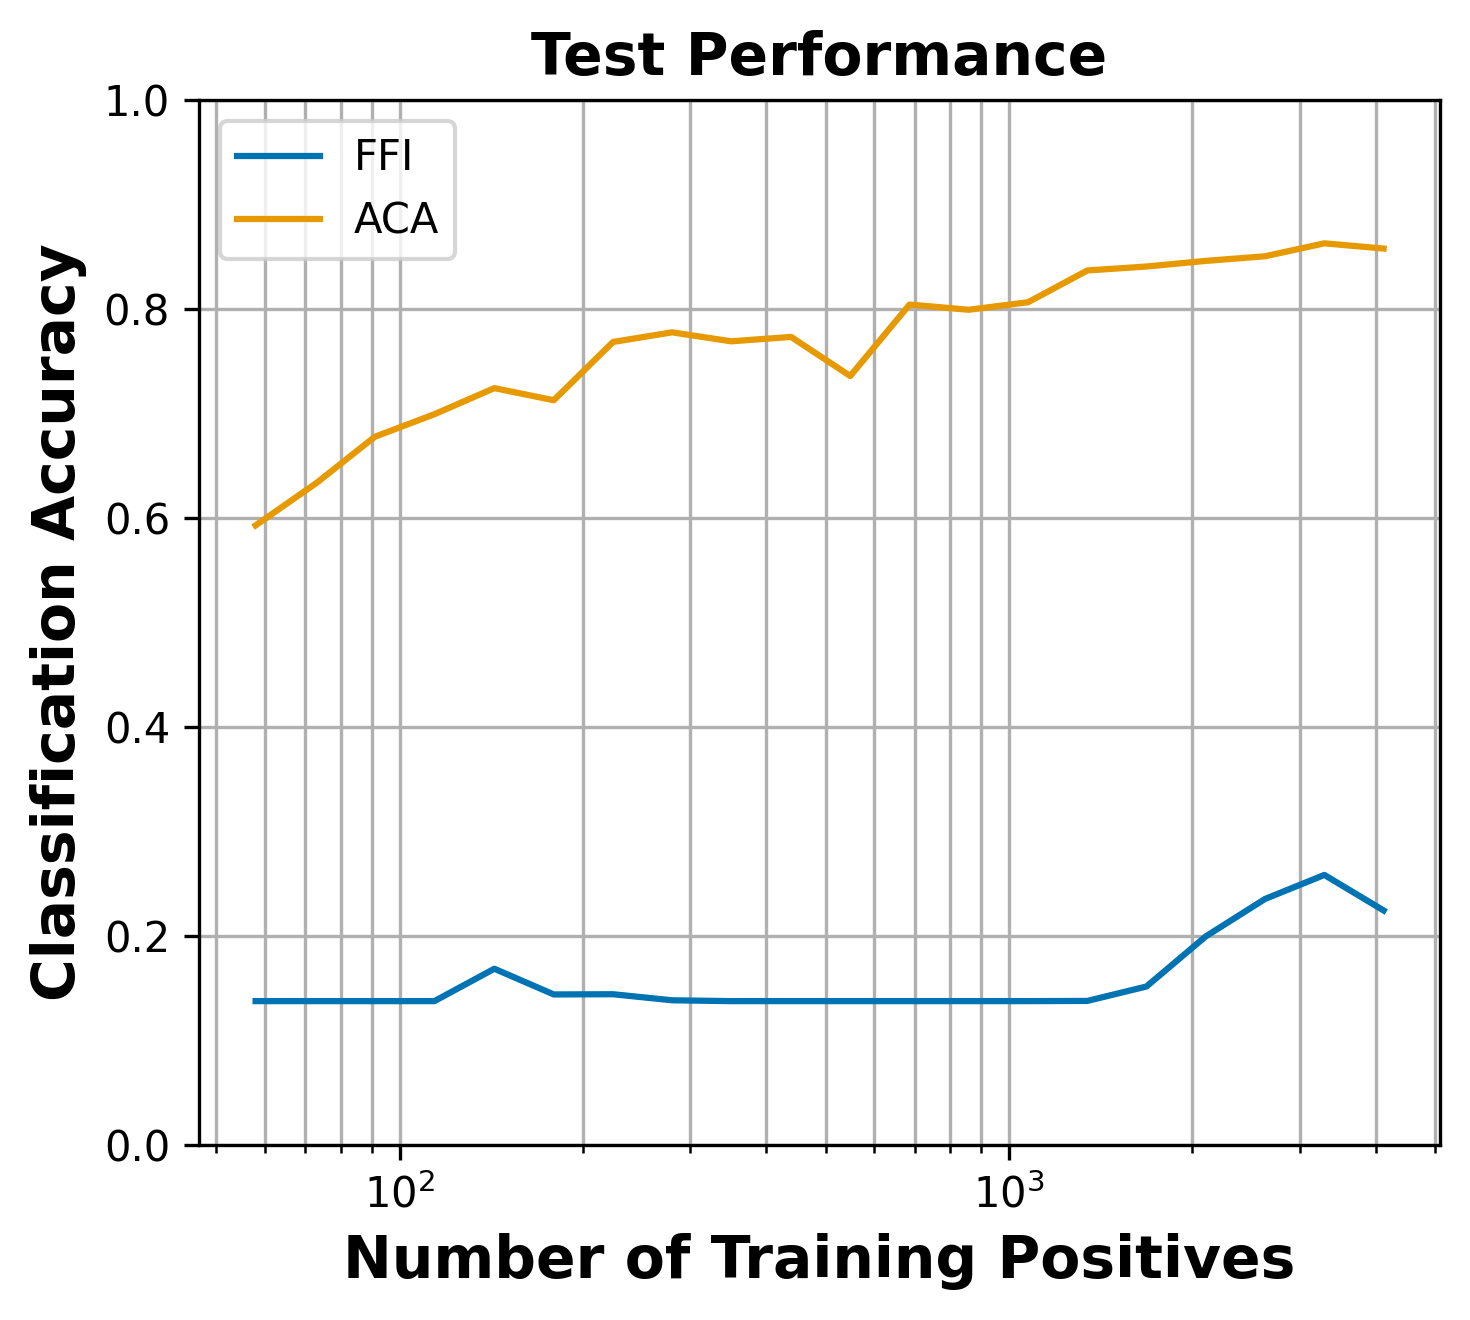

In [187]:
accuracy.to_csv("Data/vol-chip-accuracy.csv")
accuracy = pd.read_csv('Data/vol-chip-accuracy.csv')

methods = ['FFI', 'ACA'] #, 'MCA', 'AMCA']

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5), dpi=300)

ax.set_title('Test Performance', fontsize=14, weight='bold')
for i, method in enumerate(methods):
    df_ = accuracy[accuracy['Method'] == method]
    
    sns.lineplot(x="TrainSize", y="Accuracy", 
                 data=df_[df_['Train/Test'] == 'Test'], 
                 label=method, ci='sd', ax=ax)

ax.set_ylabel('Classification Accuracy', fontsize=14, weight='bold')
ax.set_xlabel('Number of Training Positives', fontsize=14, weight='bold')
ax.set_ylim((0., 1.0))
ax.set_xscale('log')
ax.grid(which="both", axis="both")


# plt.subplots_adjust(wspace=0.2)
plt.tight_layout()
plt.savefig('Images/dPCR_Effect_of_Volume.pdf')
plt.show()